#**Niave bayes and KNN**

**calling initial libraries**

In [ ]:
#for splitting the dataframes

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# for calling the models




#for calling the model performance metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:
import pandas as pd

# Load the uploaded dataset
file_path = '/content/dataset epma preprocessed1.xlsx'

epma2 = pd.read_excel(file_path)

# Display the first few rows of the dataset to understand its structure
epma2.head()


,NiO,F,Cr2O3,Na2O,MnO,ZnO,FeO,K2O,CaO,SiO2,TiO2,V2O3,MgO,Al2O3,T
0,0.000000,0.098655,0.087694,0.435239,0.315789,0.000000,0.426921,0.000000,-0.086134,-0.595574,-0.130038,1.020490,-1.177918,0.593104,2
1,0.440476,0.040359,0.117397,0.375729,0.210526,0.000000,0.387392,0.000000,-0.614105,-0.442478,-0.325993,0.225537,-0.904376,0.375515,2
2,0.333333,0.053812,0.239038,0.249708,0.035088,0.102564,0.158591,0.050847,0.903376,-0.501964,0.472235,0.478476,0.231962,0.674571,2
3,0.000000,0.170404,0.147100,0.289965,0.180702,0.461538,0.148151,0.000000,-0.087882,-0.190238,0.881435,1.598638,0.104901,0.709633,3
4,0.261905,0.000000,0.578501,0.283547,0.075439,0.000000,0.098821,0.042373,-0.332637,0.514373,-0.470077,-0.677820,0.629792,-0.444826,1


#**Niave bayes**

Fold 1 Metrics:
  Accuracy: 0.5672
  Precision: 0.5606
  Recall: 0.5672
  F1-Score: 0.5468
Fold 2 Metrics:
  Accuracy: 0.5970
  Precision: 0.5822
  Recall: 0.5970
  F1-Score: 0.5855
Fold 3 Metrics:
  Accuracy: 0.5970
  Precision: 0.5904
  Recall: 0.5970
  F1-Score: 0.5601
Fold 4 Metrics:
  Accuracy: 0.5522
  Precision: 0.5586
  Recall: 0.5522
  F1-Score: 0.5529
Fold 5 Metrics:
  Accuracy: 0.5909
  Precision: 0.5664
  Recall: 0.5909
  F1-Score: 0.5756

Average Metrics Across All Folds:
  Accuracy: 0.5809
  Precision: 0.5716
  Recall: 0.5809
  F1-Score: 0.5642


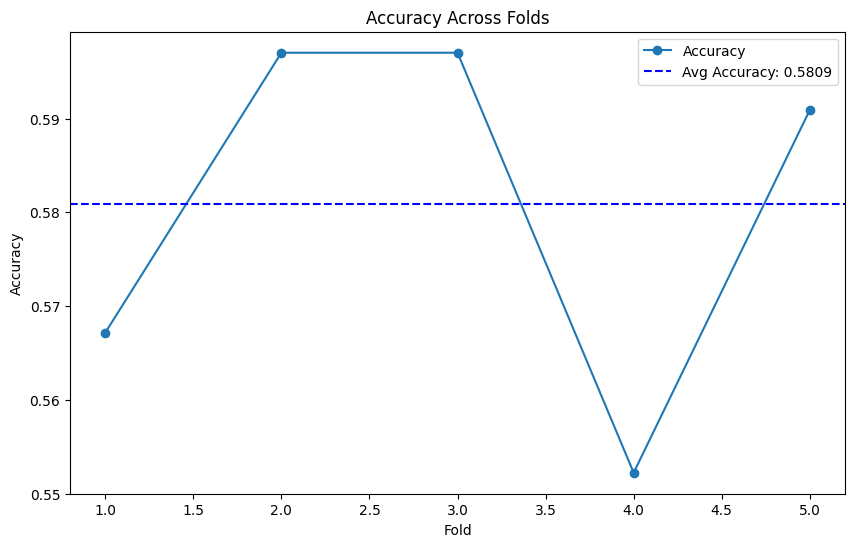

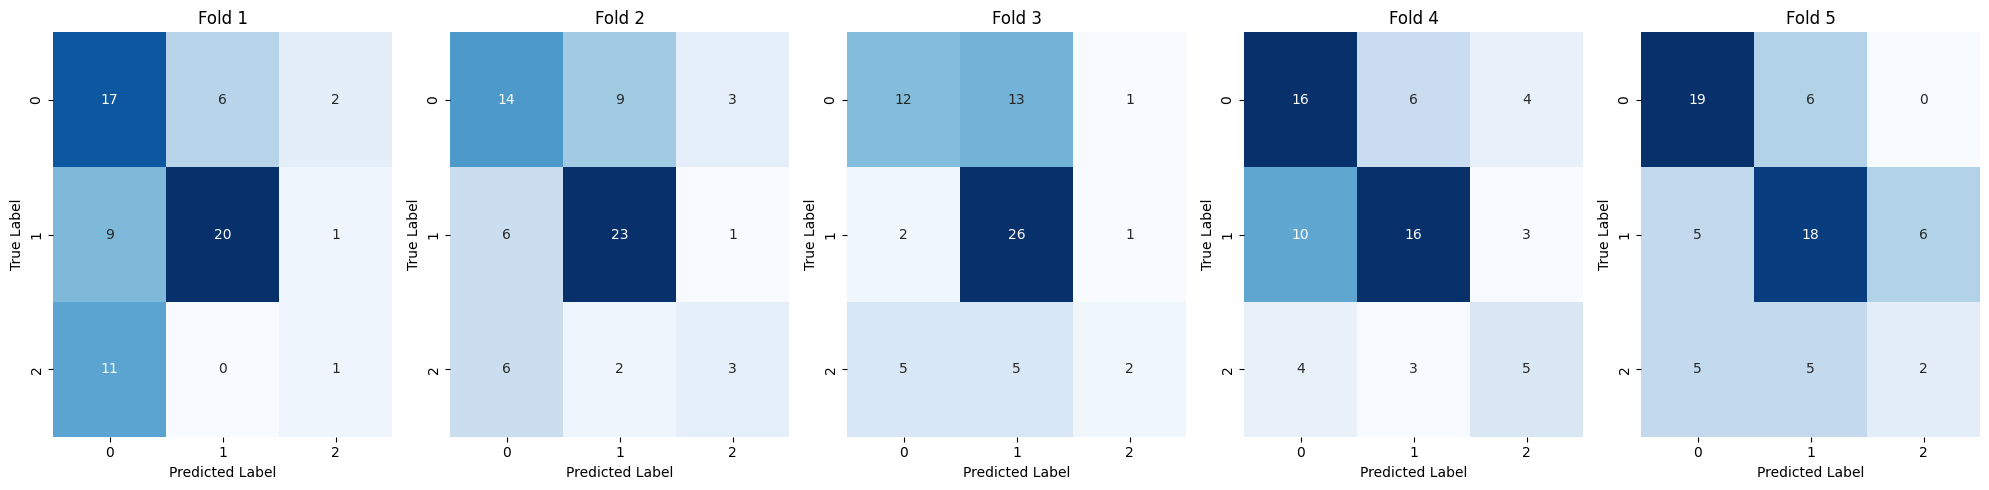


Test Set Metrics:
  Accuracy: 0.4643
  Precision: 0.4616
  Recall: 0.4643
  F1-Score: 0.4585


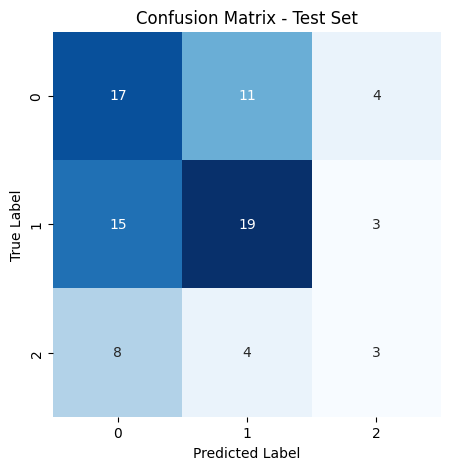

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Splitting the dataset
X = epma2.drop(columns=['T'])
y = epma2['T']

# Stratified split of the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Function to train and evaluate the model
def train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold):

    # Initialize the Gaussian Naive Bayes Classifier

    nb_model = GaussianNB()

    nb_model.fit(X_train_fold, y_train_fold)

    y_val_pred = nb_model.predict(X_val_fold)

    accuracy = accuracy_score(y_val_fold, y_val_pred)

    return accuracy, nb_model

# Store fold metrics
fold_accuracies = []
fold_metrics = {
    'precision': [],
    'recall': [],
    'f1_score': [],
    'confusion_matrices': [],
    'roc_curves': [],
    'auc_scores': []
}
best_model = None
best_accuracy = 0

# Cross-validation
for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    accuracy, model = train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold)

    fold_accuracies.append(accuracy)

    # Validate additional metrics

    y_val_pred = model.predict(X_val_fold)
    y_val_prob = model.predict_proba(X_val_fold)[:, 1] if len(model.classes_) == 2 else None
    precision = precision_score(y_val_fold, y_val_pred, average="weighted")
    recall = recall_score(y_val_fold, y_val_pred, average="weighted")
    f1 = f1_score(y_val_fold, y_val_pred, average="weighted")
    confusion = confusion_matrix(y_val_fold, y_val_pred)

    if y_val_prob is not None:
        fpr, tpr, _ = roc_curve(y_val_fold, y_val_prob)
        auc_score = roc_auc_score(y_val_fold, y_val_prob)
        fold_metrics['roc_curves'].append((fpr, tpr))
        fold_metrics['auc_scores'].append(auc_score)

    fold_metrics['precision'].append(precision)
    fold_metrics['recall'].append(recall)
    fold_metrics['f1_score'].append(f1)
    fold_metrics['confusion_matrices'].append(confusion)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model

    print(f"Fold {fold + 1} Metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    if y_val_prob is not None:
        print(f"  AUC Score: {auc_score:.4f}")

# Average Metrics
avg_accuracy = np.mean(fold_accuracies)
avg_precision = np.mean(fold_metrics['precision'])
avg_recall = np.mean(fold_metrics['recall'])
avg_f1_score = np.mean(fold_metrics['f1_score'])
avg_auc_score = np.mean(fold_metrics['auc_scores']) if fold_metrics['auc_scores'] else None

print("\nAverage Metrics Across All Folds:")
print(f"  Accuracy: {avg_accuracy:.4f}")
print(f"  Precision: {avg_precision:.4f}")
print(f"  Recall: {avg_recall:.4f}")
print(f"  F1-Score: {avg_f1_score:.4f}")
if avg_auc_score is not None:
    print(f"  Average AUC Score: {avg_auc_score:.4f}")

# Save the best model
joblib.dump(best_model, 'best_naive_bayes_model.pkl')

# Plot Metrics
folds = range(1, len(fold_accuracies) + 1)
plt.figure(figsize=(10, 6))
plt.plot(folds, fold_accuracies, marker='o', label='Accuracy')
plt.axhline(avg_accuracy, color='blue', linestyle='--', label=f'Avg Accuracy: {avg_accuracy:.4f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Accuracy Across Folds')
plt.legend()
plt.show()

# Confusion Matrix Visualization as Subplots
fig, axes = plt.subplots(1, len(fold_metrics['confusion_matrices']), figsize=(20, 5))
for fold, (confusion, ax) in enumerate(zip(fold_metrics['confusion_matrices'], axes), start=1):
    sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'Fold {fold}')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

# ROC Curve Visualization
if fold_metrics['roc_curves']:
    plt.figure(figsize=(10, 6))
    for fold, (fpr, tpr) in enumerate(fold_metrics['roc_curves'], start=1):
        plt.plot(fpr, tpr, label=f'Fold {fold} (AUC = {fold_metrics["auc_scores"][fold - 1]:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves Across Folds')
    plt.legend()
    plt.show()

# Test Set Evaluation
y_test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
y_test_prob = best_model.predict_proba(X_test)[:, 1] if len(best_model.classes_) == 2 else None
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')
test_confusion = confusion_matrix(y_test, y_test_pred)

test_auc = roc_auc_score(y_test, y_test_prob) if y_test_prob is not None else None

print("\nTest Set Metrics:")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1-Score: {test_f1:.4f}")
if test_auc is not None:
    print(f"  AUC Score: {test_auc:.4f}")

# Test Confusion Matrix
plt.figure(figsize=(5, 5))
sns.heatmap(test_confusion, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Test ROC Curve
if y_test_prob is not None:
    fpr, tpr, _ = roc_curve(y_test, y_test_prob)
    plt.figure(figsize=(7, 7))
    plt.plot(fpr, tpr, label=f'Test ROC Curve (AUC = {test_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Test ROC Curve')
    plt.legend()
    plt.show()


#**k NN**

Fold 1 Metrics:
  Accuracy: 0.6866
  Precision: 0.6669
  Recall: 0.6866
  F1-Score: 0.6675
Fold 2 Metrics:
  Accuracy: 0.7910
  Precision: 0.7930
  Recall: 0.7910
  F1-Score: 0.7754
Fold 3 Metrics:
  Accuracy: 0.6418
  Precision: 0.6615
  Recall: 0.6418
  F1-Score: 0.6310
Fold 4 Metrics:
  Accuracy: 0.6716
  Precision: 0.6627
  Recall: 0.6716
  F1-Score: 0.6601
Fold 5 Metrics:
  Accuracy: 0.6970
  Precision: 0.6857
  Recall: 0.6970
  F1-Score: 0.6841

Average Metrics Across All Folds:
  Accuracy: 0.6976
  Precision: 0.6940
  Recall: 0.6976
  F1-Score: 0.6836


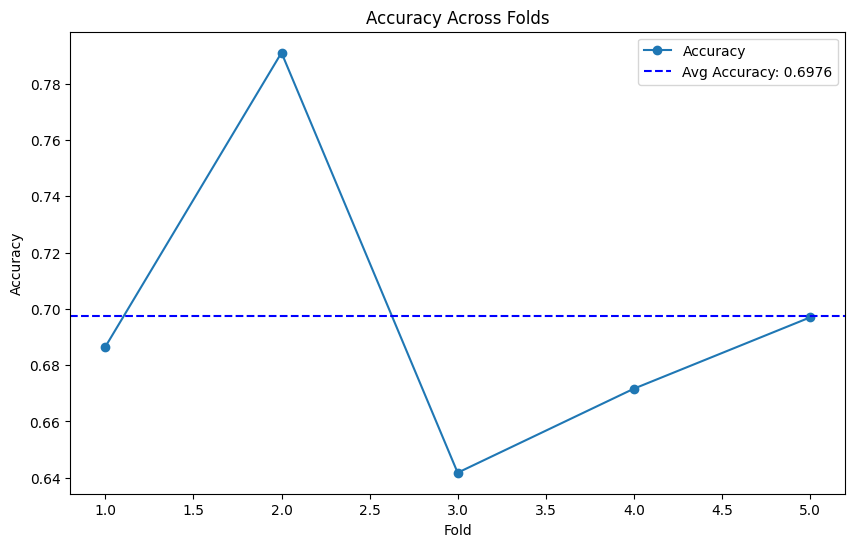

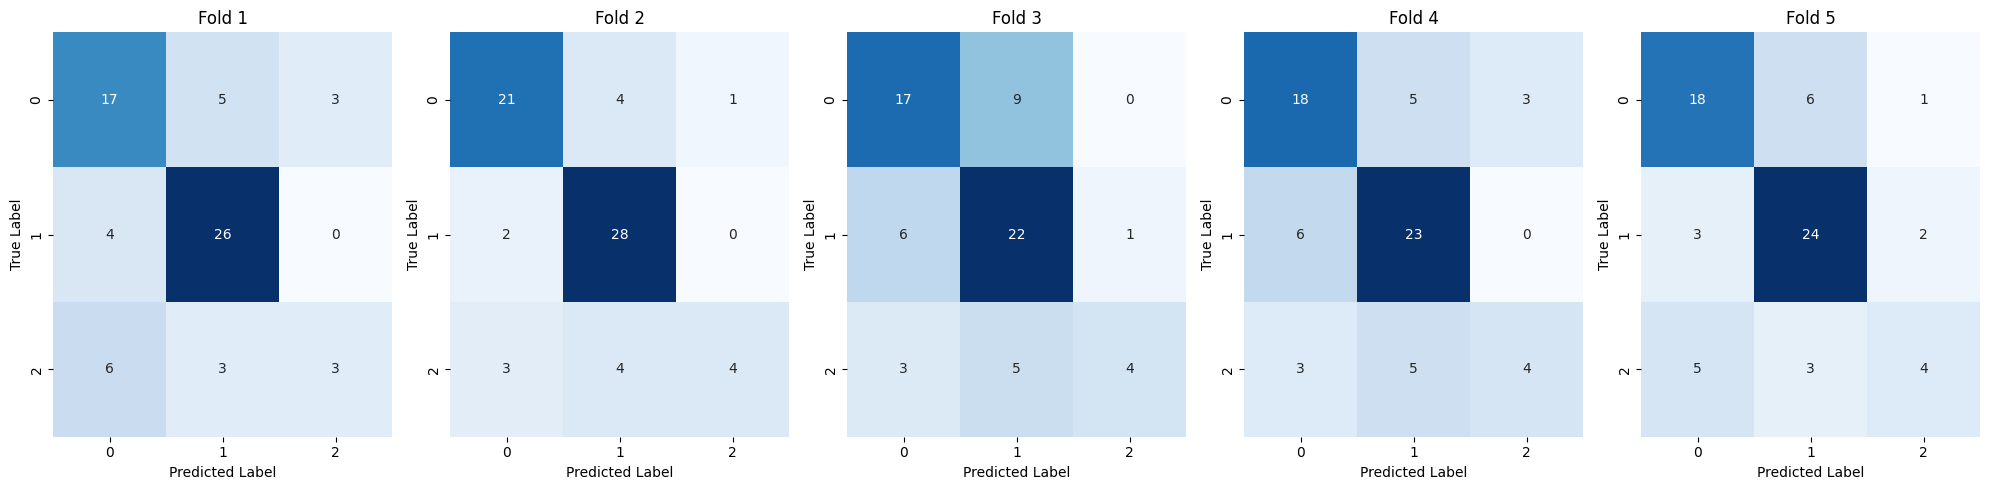


Test Set Metrics:
  Accuracy: 0.5833
  Precision: 0.5988
  Recall: 0.5833
  F1-Score: 0.5553


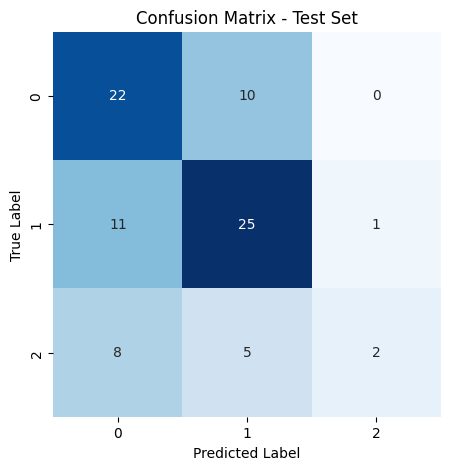

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
    roc_curve, roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Splitting the dataset
X = epma2.drop(columns=['T'])
y = epma2['T']

# Stratified split of the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Function to train and evaluate the model
def train_and_evaluate_knn(X_train_fold, y_train_fold, X_val_fold, y_val_fold, n_neighbors=5):
    # Initialize the k-NN Classifier
    knn_model = KNeighborsClassifier(n_neighbors=n_neighbors)

    knn_model.fit(X_train_fold, y_train_fold)

    y_val_pred = knn_model.predict(X_val_fold)

    accuracy = accuracy_score(y_val_fold, y_val_pred)

    return accuracy, knn_model

# Store fold metrics
fold_accuracies = []
fold_metrics = {
    'precision': [],
    'recall': [],
    'f1_score': [],
    'confusion_matrices': [],
    'roc_curves': [],
    'auc_scores': []
}
best_model = None
best_accuracy = 0

# Cross-validation
for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    accuracy, model = train_and_evaluate_knn(X_train_fold, y_train_fold, X_val_fold, y_val_fold)
    fold_accuracies.append(accuracy)

    # Validate additional metrics
    y_val_pred = model.predict(X_val_fold)
    y_val_prob = model.predict_proba(X_val_fold)[:, 1] if len(model.classes_) == 2 else None
    precision = precision_score(y_val_fold, y_val_pred, average="weighted")
    recall = recall_score(y_val_fold, y_val_pred, average="weighted")
    f1 = f1_score(y_val_fold, y_val_pred, average="weighted")
    confusion = confusion_matrix(y_val_fold, y_val_pred)

    if y_val_prob is not None:
        fpr, tpr, _ = roc_curve(y_val_fold, y_val_prob)
        auc_score = roc_auc_score(y_val_fold, y_val_prob)
        fold_metrics['roc_curves'].append((fpr, tpr))
        fold_metrics['auc_scores'].append(auc_score)

    fold_metrics['precision'].append(precision)
    fold_metrics['recall'].append(recall)
    fold_metrics['f1_score'].append(f1)
    fold_metrics['confusion_matrices'].append(confusion)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model

    print(f"Fold {fold + 1} Metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    if y_val_prob is not None:
        print(f"  AUC Score: {auc_score:.4f}")

# Average Metrics
avg_accuracy = np.mean(fold_accuracies)
avg_precision = np.mean(fold_metrics['precision'])
avg_recall = np.mean(fold_metrics['recall'])
avg_f1_score = np.mean(fold_metrics['f1_score'])
avg_auc_score = np.mean(fold_metrics['auc_scores']) if fold_metrics['auc_scores'] else None

print("\nAverage Metrics Across All Folds:")
print(f"  Accuracy: {avg_accuracy:.4f}")
print(f"  Precision: {avg_precision:.4f}")
print(f"  Recall: {avg_recall:.4f}")
print(f"  F1-Score: {avg_f1_score:.4f}")
if avg_auc_score is not None:
    print(f"  Average AUC Score: {avg_auc_score:.4f}")

# Save the best model
joblib.dump(best_model, 'best_knn_model.pkl')

# Plot Metrics
folds = range(1, len(fold_accuracies) + 1)
plt.figure(figsize=(10, 6))
plt.plot(folds, fold_accuracies, marker='o', label='Accuracy')
plt.axhline(avg_accuracy, color='blue', linestyle='--', label=f'Avg Accuracy: {avg_accuracy:.4f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Accuracy Across Folds')
plt.legend()
plt.show()

# Confusion Matrix Visualization as Subplots
fig, axes = plt.subplots(1, len(fold_metrics['confusion_matrices']), figsize=(20, 5))
for fold, (confusion, ax) in enumerate(zip(fold_metrics['confusion_matrices'], axes), start=1):
    sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'Fold {fold}')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

# Test Set Evaluation
y_test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
y_test_prob = best_model.predict_proba(X_test)[:, 1] if len(best_model.classes_) == 2 else None
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')
test_confusion = confusion_matrix(y_test, y_test_pred)

test_auc = roc_auc_score(y_test, y_test_prob) if y_test_prob is not None else None

print("\nTest Set Metrics:")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1-Score: {test_f1:.4f}")
if test_auc is not None:
    print(f"  AUC Score: {test_auc:.4f}")

# Test Confusion Matrix
plt.figure(figsize=(5, 5))
sns.heatmap(test_confusion, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Test ROC Curve
if y_test_prob is not None:
    fpr, tpr, _ = roc_curve(y_test, y_test_prob)
    plt.figure(figsize=(7, 7))
    plt.plot(fpr, tpr, label=f'Test ROC Curve (AUC = {test_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Test ROC Curve')
    plt.legend()
    plt.show()
